# Stage 1g: CB2 Decoder Baseline — Llama-3.2-3B-Instruct
## Zero-Shot and Few-Shot | Generalised LoRA for Cyberbullying Detection

---

### CB2 Dataset Overview

| Property | Value |
|----------|-------|
| Task | Binary conversation-level cyberbullying detection |
| Samples | 9,511 user pairs |
| Class 0 (not_cyberbullying) | 8,519 (89.6%) |
| Class 1 (cyberbullying) | 992 (10.4%) |
| Imbalance | **8.6:1 — severe** |
| Text representation | All messages per pair concatenated, max 300 words |
| Label source | CB_Labels.csv CB_Label column |
| Test set | ~2,343 samples |

### Critical imbalance note
A model predicting all zeros achieves 89.6% accuracy but Macro F1 ≈ 0.05 and MCC ≈ 0.00.
The primary metric (Macro F1) is specifically chosen to penalise this collapse.
AUC-ROC is added as a secondary metric because it is threshold-independent and
robust to class imbalance.

### Text construction — identical to Stages 1b/1d (encoder baselines)
Each sample is the full conversation between two users:
all messages joined chronologically with `' | '` separator, truncated to 300 words.
This is the same representation used in all CB2 encoder stages for consistency.

### All fixes from CB1 Llama experiments permanently applied

| Fix | Detail |
|-----|--------|
| Numeric output labels | 0=not_cyberbullying, 1=cyberbullying |
| New-token decode | `outputs[0][input_len:]` — never decodes the prompt |
| Word-boundary parser | `re.search(r'\b...\b')` in Level 2 |
| Split max_length | ZS: 512 | FS: 1536 |
| Smoke test | Validates digit output before full run |

**Primary Metric:** Macro F1 | **Secondary Metric:** MCC + AUC-ROC | **Seed:** 42

---
## Step 1: Install Required Libraries

In [1]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    bitsandbytes \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn \
    tqdm

print("All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 138.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 51.7 MB/s eta 0:00:00
All libraries installed successfully.


---
## Step 2: Imports and Setup

In [2]:
import os, re, random, gc
from typing import List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef, roc_auc_score,
)
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
)
from google.colab import drive, userdata


def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    print(f"All random seeds fixed to {seed}.")


set_all_seeds(42)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

if not os.path.isdir("/content/drive/MyDrive"):
    drive.mount("/content/drive")
    print("Google Drive mounted.")
else:
    print("Google Drive already mounted.")

print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f"  GPU : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

All random seeds fixed to 42.
Mounted at /content/drive
Google Drive mounted.
Device: GPU
  GPU : NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_PATH   = "/content/drive/MyDrive/Datasets/CB2/"
COMM_PATH   = BASE_PATH + "5. Communication_Data_Among_Users.csv"
LABELS_PATH = BASE_PATH + "6. CB_Labels.csv"
OUTPUT_DIR  = "/content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B"

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME  = "meta-llama/Llama-3.2-3B-Instruct"
MODEL_SHORT = "Llama-3.2-3B"

# ── Generation ────────────────────────────────────────────────────────────────
MAX_NEW_TOKENS   = 3     # single digit 0 or 1
MAX_INPUT_LEN_ZS = 512   # zero-shot prompt
MAX_INPUT_LEN_FS = 1536  # few-shot: 4 examples (2 per class) + conversation

# ── Text construction — identical to Stages 1b/1d ────────────────────────────
MAX_CONV_WORDS = 300     # ~390 subword tokens; consistent with encoder stages

# ── Dataset split ─────────────────────────────────────────────────────────────
TEST_RATIO           = 0.25
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Labels — binary ───────────────────────────────────────────────────────────
LABEL_MAPPING = {
    "not_cyberbullying": 0,
    "cyberbullying":     1,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())
NUM_LABELS   = 2

# ── Few-shot ──────────────────────────────────────────────────────────────────
N_EXAMPLES_PER_CLASS = 2   # 2 × 2 = 4 total (binary task)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration loaded.")
print(f"  Model          : {MODEL_NAME}")
print(f"  Task           : Binary CB2 (conversation-level)")
print(f"  Output format  : NUMERIC (0=not_cb, 1=cyberbullying)")
print(f"  MAX_CONV_WORDS : {MAX_CONV_WORDS} (same as encoder stages 1b/1d)")
print(f"  MAX_INPUT_LEN  : ZS={MAX_INPUT_LEN_ZS} | FS={MAX_INPUT_LEN_FS}")
print(f"  Max new tokens : {MAX_NEW_TOKENS}")
print(f"  Few-shot       : {N_EXAMPLES_PER_CLASS} per class = {N_EXAMPLES_PER_CLASS * NUM_LABELS} total")
print(f"  Seed           : {RANDOM_STATE}")
print(f"  Output         : {OUTPUT_DIR}")

Configuration loaded.
  Model          : meta-llama/Llama-3.2-3B-Instruct
  Task           : Binary CB2 (conversation-level)
  Output format  : NUMERIC (0=not_cb, 1=cyberbullying)
  MAX_CONV_WORDS : 300 (same as encoder stages 1b/1d)
  MAX_INPUT_LEN  : ZS=512 | FS=1536
  Max new tokens : 3
  Few-shot       : 2 per class = 4 total
  Seed           : 42
  Output         : /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B


---
## Step 4: Text Construction Functions

Identical to encoder stages 1b/1d — all messages per pair joined chronologically with `' | '` separator, truncated to 300 words.

In [4]:
def build_conversation_text(messages: List[str],
                             max_words: int = MAX_CONV_WORDS) -> str:
    """
    Join all messages for a user pair chronologically.
    Separator: ' | ' — identical to encoder stages 1b/1d.
    Truncated to max_words for token budget.
    """
    joined = " | ".join(str(m).strip() for m in messages if str(m).strip())
    words  = joined.split()
    if len(words) > max_words:
        joined = " ".join(words[:max_words])
    return joined


def preprocess_message(text: str) -> str:
    """Light cleaning — preserves message meaning for decoder model."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\.\S+", "[URL]", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Smoke test
_test_msgs = ["Hello there", "You are so stupid", "I hate you"]
_built = build_conversation_text(_test_msgs, max_words=10)
print(f"Text builder test: '{_built}'")
print("Text construction functions defined.")

Text builder test: 'Hello there | You are so stupid | I hate'
Text construction functions defined.


---
## Step 5: Load and Build CB2 Dataset

In [5]:
print("=" * 60)
print("CB2 DATASET CONSTRUCTION")
print("=" * 60)

# Load CB Labels (File 6) — conversation-level binary labels
print("[1] Loading CB Labels...")
labels_df = pd.read_csv(LABELS_PATH)
print(f"  Shape: {labels_df.shape}")
vc = labels_df['CB_Label'].value_counts()
print(f"  not_cyberbullying (0): {vc[0]:,} ({vc[0]/len(labels_df)*100:.1f}%)")
print(f"  cyberbullying     (1): {vc[1]:,} ({vc[1]/len(labels_df)*100:.1f}%)")
print(f"  Imbalance ratio       : {vc[0]/vc[1]:.2f}x  (SEVERE)")

# Load Communication Data (File 5) — message-level text
print("\n[2] Loading Communication Data...")
comm_df = pd.read_csv(COMM_PATH)
print(f"  Shape: {comm_df.shape}")
comm_df['Message'] = comm_df['Message'].apply(preprocess_message)
comm_df = comm_df[comm_df['Message'].str.len() > 0]

# Build conversation texts — group by user pair, join chronologically
print("\n[3] Building conversation texts (max 300 words per pair)...")
conv_texts = {}
for (u1, u2), grp in comm_df.groupby(['User1 ID', 'User2 ID']):
    msgs = grp.sort_values(['Date', 'Time'])['Message'].tolist()
    conv_texts[(u1, u2)] = build_conversation_text(msgs)

print(f"  Built {len(conv_texts):,} conversation texts.")

# Merge with CB Labels
print("\n[4] Merging with CB Labels...")
records = []
for _, row in labels_df.iterrows():
    u1, u2 = row['User1 ID'], row['User2 ID']
    text   = conv_texts.get((u1, u2), "")
    if text.strip():
        label = "cyberbullying" if row['CB_Label'] == 1 else "not_cyberbullying"
        records.append({"text": text, "label": label,
                        "user1": u1, "user2": u2})

df = pd.DataFrame(records)
print(f"  Final dataset: {len(df):,} samples")
print(f"  Missing texts: {len(labels_df) - len(df):,} pairs dropped")

print("\nClass distribution:")
for label, count in df["label"].value_counts().items():
    print(f"  {label:<22} {count:>6}  ({count/len(df)*100:.1f}%)")

CB2 DATASET CONSTRUCTION
[1] Loading CB Labels...
  Shape: (9511, 7)
  not_cyberbullying (0): 8,519 (89.6%)
  cyberbullying     (1): 992 (10.4%)
  Imbalance ratio       : 8.59x  (SEVERE)

[2] Loading Communication Data...
  Shape: (90356, 6)

[3] Building conversation texts (max 300 words per pair)...
  Built 9,511 conversation texts.

[4] Merging with CB Labels...
  Final dataset: 9,511 samples
  Missing texts: 0 pairs dropped

Class distribution:
  not_cyberbullying        8519  (89.6%)
  cyberbullying             992  (10.4%)


---
## Step 6: Stratified Split with Near-Duplicate Removal

In [6]:
print("=" * 60)
print("DATASET SPLITTING — 75/25 stratified (same as encoder stages)")
print("=" * 60)

# Exact dedup first
before = len(df)
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"[1] Removed {before - len(df):,} exact duplicates -> {len(df):,} remaining")

# Stratified 75/25 split
train_df, test_df = train_test_split(
    df, test_size=TEST_RATIO,
    random_state=RANDOM_STATE, stratify=df["label"])
print(f"[2] Stratified split -> Train: {len(train_df):,} | Test: {len(test_df):,}")

# Near-duplicate removal
print(f"[3] Near-duplicate check (threshold={SIMILARITY_THRESHOLD})...")
all_texts    = list(train_df["text"].values) + list(test_df["text"].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                               min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_df)]
test_vecs    = tfidf_matrix[len(train_df):]

leaked = []
for start in range(0, len(test_df), 500):
    end  = min(start + 500, len(test_df))
    sims = cosine_similarity(test_vecs[start:end], train_vecs)
    mask = sims.max(axis=1) >= SIMILARITY_THRESHOLD
    leaked.extend(test_df.index[start:end][mask].tolist())

if leaked:
    leaked_samples = test_df.loc[leaked]
    test_df  = test_df.drop(leaked).reset_index(drop=True)
    train_df = pd.concat([train_df, leaked_samples], ignore_index=True)
    print(f"  Moved {len(leaked)} near-duplicates to train.")
else:
    train_df = train_df.reset_index(drop=True)
    test_df  = test_df.reset_index(drop=True)
    print("  No near-duplicates found.")

overlap = set(train_df["text"]).intersection(set(test_df["text"]))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} samples!"
print("Zero train/test overlap confirmed.")
print(f"Final -> Train: {len(train_df):,} | Test: {len(test_df):,}")

print("\nTest class distribution:")
for label, count in test_df["label"].value_counts().items():
    print(f"  {label:<22} {count:>6}  ({count/len(test_df)*100:.1f}%)")

x_test = test_df["text"].values
y_test  = test_df["label"].map(LABEL_MAPPING).values
print(f"\nTest set ready: {len(x_test):,} samples")

DATASET SPLITTING — 75/25 stratified (same as encoder stages)
[1] Removed 1 exact duplicates -> 9,510 remaining
[2] Stratified split -> Train: 7,132 | Test: 2,378
[3] Near-duplicate check (threshold=0.9)...
  Moved 32 near-duplicates to train.
Zero train/test overlap confirmed.
Final -> Train: 7,164 | Test: 2,346

Test class distribution:
  not_cyberbullying        2104  (89.7%)
  cyberbullying             242  (10.3%)

Test set ready: 2,346 samples


---
## Step 7: Load Model and Tokenizer

In [7]:
print("Loading model:", MODEL_NAME)
HF_TOKEN = userdata.get("HF_TOKEN")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    token=HF_TOKEN,
)
model.config.use_cache = False
model.eval()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"

n_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded.  Parameters: {n_params/1e9:.2f}B")
if hasattr(model, "hf_device_map"):
    print(f"  Device map : {model.hf_device_map}")
if torch.cuda.is_available():
    print(f"  VRAM used  : {torch.cuda.memory_allocated(0)/1e9:.2f} GB")

Loading model: meta-llama/Llama-3.2-3B-Instruct


config.json:   0%|          | 0.00/878 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

Model loaded.  Parameters: 1.80B
  VRAM used  : 2.24 GB


---
## Step 8: Prompt Builder

Binary output: 0 (not_cyberbullying) or 1 (cyberbullying). Prompt describes the task as conversation-level classification between two school students.

In [8]:
def build_prompt(conversation: str,
                 examples: Optional[List[Tuple[str, int]]] = None) -> str:
    """
    Build zero-shot or few-shot prompt for CB2 binary classification.
    Input: concatenated conversation text (max 300 words).
    Output: single digit — 0 (not_cyberbullying) or 1 (cyberbullying).
    """
    system_msg = (
        "You are a cyberbullying detection classifier. "
        "You will be given a conversation between two school students.\n\n"
        "Classify the conversation into exactly one of these categories:\n"
        "  0: not_cyberbullying — The conversation does not contain cyberbullying.\n"
        "  1: cyberbullying — The conversation contains cyberbullying behaviour.\n\n"
        "Rules:\n"
        "- Reply with ONLY the category number (0 or 1).\n"
        "- Do NOT write the category name.\n"
        "- Do NOT explain your answer.\n"
        "- Your entire response must be a single digit."
    )

    if examples:
        ex_str = "\n\nExamples:\n"
        for ex_conv, ex_label in examples:
            # Truncate example conversation for prompt budget
            ex_words = ex_conv.split()[:100]
            ex_short  = " ".join(ex_words)
            ex_str   += f'Conversation: "{ex_short}"\nCategory number: {ex_label}\n\n'
        user_msg = (
            f"{ex_str}Now classify this conversation:\n"
            f'Conversation: "{conversation}"\nCategory number:'
        )
    else:
        user_msg = (
            f'Classify this conversation:\n'
            f'Conversation: "{conversation}"\nCategory number:'
        )

    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user",   "content": user_msg},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )


_test_conv = "You are so stupid | Nobody likes you | Get lost loser"
_prompt = build_prompt(_test_conv)
print("Zero-shot prompt (last 200 chars):")
print(_prompt[-200:])
print("\nPrompt builder defined. Output: 0 or 1.")

Zero-shot prompt (last 200 chars):
r_id|>user<|end_header_id|>

Classify this conversation:
Conversation: "You are so stupid | Nobody likes you | Get lost loser"
Category number:<|eot_id|><|start_header_id|>assistant<|end_header_id|>



Prompt builder defined. Output: 0 or 1.


---
## Step 9: Label Parser — Binary (0/1)

Only accepts digits 0 or 1. Out-of-range digits (2–9) default to 0. Self-test includes CB2-specific cases.

In [9]:
def parse_label(generated_text: str) -> int:
    """
    Binary digit parser — 0 or 1 only.

    Level 1: First valid digit (0 or 1) in generated text.
    Level 2: Word-boundary label name match.
    Level 3: Default → 0 (majority class — not_cyberbullying).
    """
    response = generated_text.strip()

    # Level 1: first valid binary digit
    for ch in response:
        if ch in "01":
            return int(ch)

    # Level 2: word-boundary label name fallback
    response_lower = response.lower()
    for label, idx in LABEL_MAPPING.items():
        if re.search(r"\b" + re.escape(label.lower()) + r"\b", response_lower):
            return idx

    # Level 3: default → majority class
    return 0


# ── Self-test ──────────────────────────────────────────────────────────────────
_tests = [
    ("0",                  0, "clean zero"),
    ("1",                  1, "clean one"),
    ("  1  ",              1, "digit with whitespace"),
    ("Category number: 0", 0, "digit after text"),
    ("The answer is 1.",   1, "digit in sentence"),
    ("cyberbullying",      1, "text fallback L2"),
    ("not_cyberbullying",  0, "text fallback L2"),
    ("garbage output",     0, "default fallback"),
    # CB2-specific: '2' must NOT be accepted — only 0/1 valid
    ("2",                  0, "digit 2 must default to 0"),
    ("Category: 5",        0, "out-of-range digit defaults to 0"),
]
print("Parser self-test:")
all_pass = True
for text, expected, note in _tests:
    got    = parse_label(text)
    status = "PASS" if got == expected else "FAIL"
    if got != expected: all_pass = False
    print(f"  [{status}] '{text}' -> {got} (expected {expected})  # {note}")
print(f"\n  All tests passed: {all_pass}")
assert all_pass, "Fix the parser before running inference."
print("Label parser defined (binary 0/1).")

Parser self-test:
  [PASS] '0' -> 0 (expected 0)  # clean zero
  [PASS] '1' -> 1 (expected 1)  # clean one
  [PASS] '  1  ' -> 1 (expected 1)  # digit with whitespace
  [PASS] 'Category number: 0' -> 0 (expected 0)  # digit after text
  [PASS] 'The answer is 1.' -> 1 (expected 1)  # digit in sentence
  [PASS] 'cyberbullying' -> 1 (expected 1)  # text fallback L2
  [PASS] 'not_cyberbullying' -> 0 (expected 0)  # text fallback L2
  [PASS] 'garbage output' -> 0 (expected 0)  # default fallback
  [PASS] '2' -> 0 (expected 0)  # digit 2 must default to 0
  [PASS] 'Category: 5' -> 0 (expected 0)  # out-of-range digit defaults to 0

  All tests passed: True
Label parser defined (binary 0/1).


---
## Step 10: Inference Function

In [10]:
def run_inference(texts: np.ndarray,
                  examples: Optional[List[Tuple[str, int]]] = None,
                  desc: str = "Inference",
                  max_input_len: int = MAX_INPUT_LEN_ZS) -> np.ndarray:
    """Greedy inference — binary output 0/1."""
    predictions  = []
    level_counts = {1: 0, 2: 0, 3: 0}

    for text in tqdm(texts, desc=desc):
        prompt = build_prompt(str(text), examples)

        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=max_input_len,
            padding=False,
        ).to(model.device)

        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                temperature=1.0,
                pad_token_id=tokenizer.eos_token_id,
            )

        new_tokens = outputs[0][input_len:]
        generated  = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

        pred = parse_label(generated)

        if any(ch in generated for ch in "01"):
            level_counts[1] += 1
        elif any(re.search(r"\b" + re.escape(l.lower()) + r"\b",
                           generated.lower()) for l in LABEL_MAPPING):
            level_counts[2] += 1
        else:
            level_counts[3] += 1

        predictions.append(pred)

    n = len(texts)
    print(f"  Parser level breakdown:")
    print(f"    L1 digit     : {level_counts[1]:>6} / {n}  ({level_counts[1]/n*100:.1f}%)")
    print(f"    L2 text name : {level_counts[2]:>6} / {n}  ({level_counts[2]/n*100:.1f}%)")
    print(f"    L3 default   : {level_counts[3]:>6} / {n}  ({level_counts[3]/n*100:.1f}%)")
    return np.array(predictions)

---
## Step 11: Evaluation Function

**Three metrics:** Macro F1 (primary), MCC (secondary), AUC-ROC (secondary). AUC-ROC is added because it is threshold-independent and robust to the 8.6:1 class imbalance. Includes class-collapse warning if model predicts <2% cyberbullying.

In [11]:
def evaluate_dataset(y_true: np.ndarray,
                     y_pred: np.ndarray,
                     dataset_name: str) -> dict:
    """
    CB2 binary evaluation.
    Primary: Macro F1 | Secondary: MCC + AUC-ROC
    AUC-ROC added because it is threshold-independent and
    robust to the 8.6:1 class imbalance.
    """
    print(f"\n{'='*65}")
    print(f"EVALUATION -- {dataset_name}")
    print(f"{'='*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    binary_f1    = f1_score(y_true, y_pred, average="binary",   zero_division=0)
    macro_prec   = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_rec    = recall_score(y_true, y_pred, average="macro",    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    try:
        auc_roc = roc_auc_score(y_true, y_pred)
    except Exception:
        auc_roc = float("nan")

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  <- PRIMARY METRIC")
    print(f"  MCC               : {mcc:.4f}  <- SECONDARY METRIC")
    print(f"  AUC-ROC           : {auc_roc:.4f}  <- SECONDARY METRIC")
    print(f"  Binary F1 (CB=1)  : {binary_f1:.4f}")
    print(f"  Macro Precision   : {macro_prec:.4f}")
    print(f"  Macro Recall      : {macro_rec:.4f}")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")

    print("\n  Per-Class Report:")
    print(classification_report(y_true, y_pred,
                                labels=[0, 1],
                                target_names=TARGET_NAMES,
                                zero_division=0, digits=4))

    # Imbalance warning
    pred_cb = (y_pred == 1).sum()
    pred_pct = pred_cb / len(y_pred) * 100
    print(f"  Predicted cyberbullying: {pred_cb}/{len(y_pred)} ({pred_pct:.1f}%)")
    if pred_pct < 2:
        print("  WARNING: Near-complete class collapse — model predicting mostly 0.")

    cm      = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f"Confusion Matrix (Counts)\n{dataset_name}", fontsize=12)
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].tick_params(axis="x", rotation=15)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens", ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                vmin=0, vmax=1)
    axes[1].set_title(f"Confusion Matrix (Normalised)\n{dataset_name}", fontsize=12)
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].tick_params(axis="x", rotation=15)

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"cm_{dataset_name.replace(' ', '_')}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved -> {save_path}")

    return dict(accuracy=accuracy, macro_f1=macro_f1, mcc=mcc,
                auc_roc=auc_roc, binary_f1=binary_f1,
                macro_precision=macro_prec, macro_recall=macro_rec,
                weighted_f1=weighted_f1, balanced_accuracy=bal_accuracy)


print("Evaluation function defined (Macro F1 + MCC + AUC-ROC).")

Evaluation function defined (Macro F1 + MCC + AUC-ROC).


---
## Step 12: Generate Few-Shot Examples

Only 4 total examples (2 per class × 2 classes). Example conversations truncated to 100 words inside `build_prompt()` to keep FS prompt within budget.

In [12]:
def get_few_shot_examples(train_df: pd.DataFrame,
                          n_per_class: int = 2,
                          seed: int = 42) -> List[Tuple[str, int]]:
    """
    Sample n_per_class examples per label.
    Returns (conversation_text, numeric_label) tuples.
    Example conversations truncated to 100 words inside build_prompt()
    to keep the FS prompt within MAX_INPUT_LEN_FS=1536.
    """
    examples = []
    for label_name in sorted(LABEL_MAPPING.keys()):
        label_id = LABEL_MAPPING[label_name]
        class_df = train_df[train_df["label"] == label_name]
        if len(class_df) < n_per_class:
            raise ValueError(
                f"Class '{label_name}' has only {len(class_df)} samples "
                f"(need {n_per_class}).")
        sampled = class_df.sample(n=n_per_class, random_state=seed)
        for _, row in sampled.iterrows():
            examples.append((row["text"], label_id))
    random.shuffle(examples)
    return examples


few_shot_examples = get_few_shot_examples(train_df, N_EXAMPLES_PER_CLASS)

print(f"Few-shot examples ({len(few_shot_examples)} total = "
      f"{N_EXAMPLES_PER_CLASS} per class × {NUM_LABELS} classes):")
for i, (conv, label_id) in enumerate(few_shot_examples):
    print(f"  [{i+1}] label={label_id} ({ID2LABEL[label_id]:<22}) {conv[:60]}...")

_check = build_prompt("test conversation text", few_shot_examples)
print("\nFew-shot prompt tail (last 300 chars):")
print(_check[-300:])

Few-shot examples (4 total = 2 per class × 2 classes):
  [1] label=0 (not_cyberbullying     ) When I added it they reverted my edition Not they added it a...
  [2] label=1 (cyberbullying         ) biography of Lazar Kaganovich a Nice read from a fascinating...
  [3] label=0 (not_cyberbullying     ) hey kid i did not attack you and i dont appreciate the nasty...
  [4] label=1 (cyberbullying         ) Love you The guy is one of two in the category People excomm...

Few-shot prompt tail (last 300 chars):
ant to repair these false and mistake pages of Wikipedia Why dont you trying to understand Why did you blaming me This is edit warring"
Category number: 1

Now classify this conversation:
Conversation: "test conversation text"
Category number:<|eot_id|><|start_header_id|>assistant<|end_header_id|>




---
## Step 13: Zero-Shot Inference

Smoke test checks for 0 or 1 output. Watch for class collapse warning in evaluation output.

ZERO-SHOT INFERENCE — CB2 Binary
  Model      : meta-llama/Llama-3.2-3B-Instruct
  Test       : 2,346 samples
  max_length : 512 tokens
  Imbalance  : 8.6:1 — watch for class collapse


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Smoke test (Zero-shot):
  Input      : 'You are so stupid | Nobody likes you | Get lost loser'
  Generated  : '1'   <- must be 0 or 1
  Prediction : 1 = cyberbullying

Smoke test PASSED. Proceeding with full zero-shot run...



Zero-shot: 100%|██████████| 2346/2346 [07:24<00:00,  5.28it/s]


  Parser level breakdown:
    L1 digit     :   2212 / 2346  (94.3%)
    L2 text name :      0 / 2346  (0.0%)
    L3 default   :    134 / 2346  (5.7%)

EVALUATION -- Llama-3.2-3B_ZeroShot_CB2
  Accuracy          : 0.3078
  Macro F1          : 0.2922  <- PRIMARY METRIC
  MCC               : 0.0189  <- SECONDARY METRIC
  AUC-ROC           : 0.5135  <- SECONDARY METRIC
  Binary F1 (CB=1)  : 0.1872
  Macro Precision   : 0.5066
  Macro Recall      : 0.5135
  Weighted F1       : 0.3755
  Balanced Accuracy : 0.5135

  Per-Class Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9068    0.2543    0.3972      2104
    cyberbullying     0.1065    0.7727    0.1872       242

         accuracy                         0.3078      2346
        macro avg     0.5066    0.5135    0.2922      2346
     weighted avg     0.8242    0.3078    0.3755      2346

  Predicted cyberbullying: 1756/2346 (74.9%)


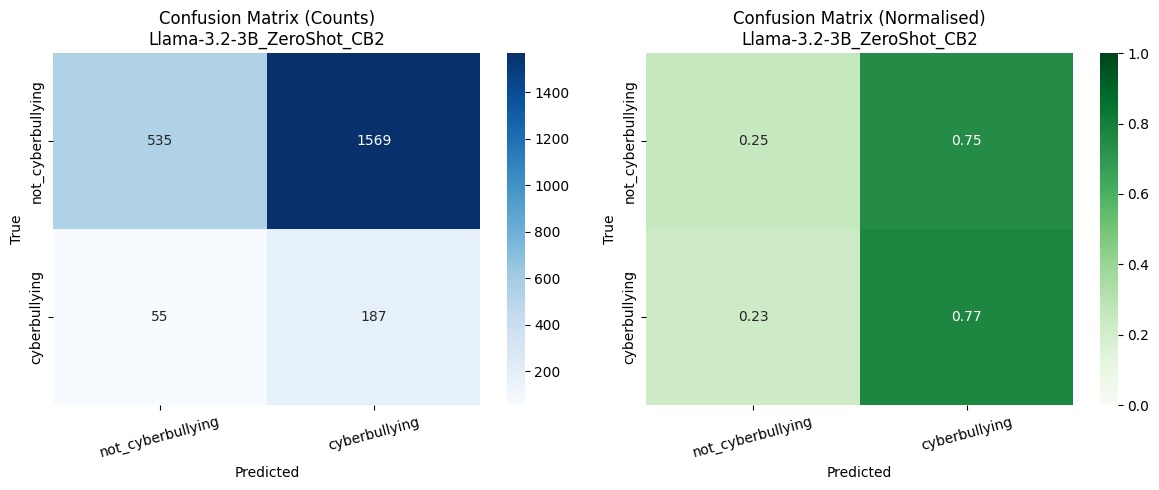

  Saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/cm_Llama-3.2-3B_ZeroShot_CB2.png


In [13]:
print("=" * 65)
print("ZERO-SHOT INFERENCE — CB2 Binary")
print(f"  Model      : {MODEL_NAME}")
print(f"  Test       : {len(x_test):,} samples")
print(f"  max_length : {MAX_INPUT_LEN_ZS} tokens")
print(f"  Imbalance  : 8.6:1 — watch for class collapse")
print("=" * 65)

_smoke_conv   = "You are so stupid | Nobody likes you | Get lost loser"
_smoke_prompt = build_prompt(_smoke_conv, None)
_smoke_inputs = tokenizer(
    _smoke_prompt, return_tensors="pt",
    truncation=True, max_length=MAX_INPUT_LEN_ZS
).to(model.device)
_smoke_in_len = _smoke_inputs["input_ids"].shape[1]

with torch.no_grad():
    _smoke_out = model.generate(
        **_smoke_inputs, max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False, pad_token_id=tokenizer.eos_token_id
    )

_smoke_generated = tokenizer.decode(
    _smoke_out[0][_smoke_in_len:], skip_special_tokens=True
).strip()
_smoke_pred = parse_label(_smoke_generated)

print(f"Smoke test (Zero-shot):")
print(f"  Input      : '{_smoke_conv}'")
print(f"  Generated  : '{_smoke_generated}'   <- must be 0 or 1")
print(f"  Prediction : {_smoke_pred} = {ID2LABEL[_smoke_pred]}")
print()

_valid = any(ch in _smoke_generated for ch in "01")
if not _valid:
    print("WARNING: smoke test did not produce 0 or 1. STOP and investigate.")
else:
    print("Smoke test PASSED. Proceeding with full zero-shot run...")

y_pred_zs  = run_inference(x_test, examples=None,
                            desc="Zero-shot", max_input_len=MAX_INPUT_LEN_ZS)
results_zs = evaluate_dataset(y_test, y_pred_zs,
                               f"{MODEL_SHORT}_ZeroShot_CB2")
results_zs["regime"] = "zero-shot"

---
## Step 14: Few-Shot Inference

FEW-SHOT INFERENCE — CB2 Binary
  Model      : meta-llama/Llama-3.2-3B-Instruct
  Examples   : 4 total (2/class × 2 classes)
  max_length : 1536 tokens


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Smoke test (Few-shot):
  Input      : 'You are so stupid | Nobody likes you | Get lost loser'
  Generated  : '1'   <- must be 0 or 1
  Prediction : 1 = cyberbullying

Smoke test PASSED. Proceeding with full few-shot run...



Few-shot: 100%|██████████| 2346/2346 [07:20<00:00,  5.33it/s]


  Parser level breakdown:
    L1 digit     :   2345 / 2346  (100.0%)
    L2 text name :      0 / 2346  (0.0%)
    L3 default   :      1 / 2346  (0.0%)

EVALUATION -- Llama-3.2-3B_FewShot_CB2
  Accuracy          : 0.4369
  Macro F1          : 0.3962  <- PRIMARY METRIC
  MCC               : 0.1568  <- SECONDARY METRIC
  AUC-ROC           : 0.6239  <- SECONDARY METRIC
  Binary F1 (CB=1)  : 0.2395
  Macro Precision   : 0.5496
  Macro Recall      : 0.6239
  Weighted F1       : 0.5206
  Balanced Accuracy : 0.6239

  Per-Class Report:
                   precision    recall  f1-score   support

not_cyberbullying     0.9600    0.3883    0.5530      2104
    cyberbullying     0.1391    0.8595    0.2395       242

         accuracy                         0.4369      2346
        macro avg     0.5496    0.6239    0.3962      2346
     weighted avg     0.8754    0.4369    0.5206      2346

  Predicted cyberbullying: 1495/2346 (63.7%)


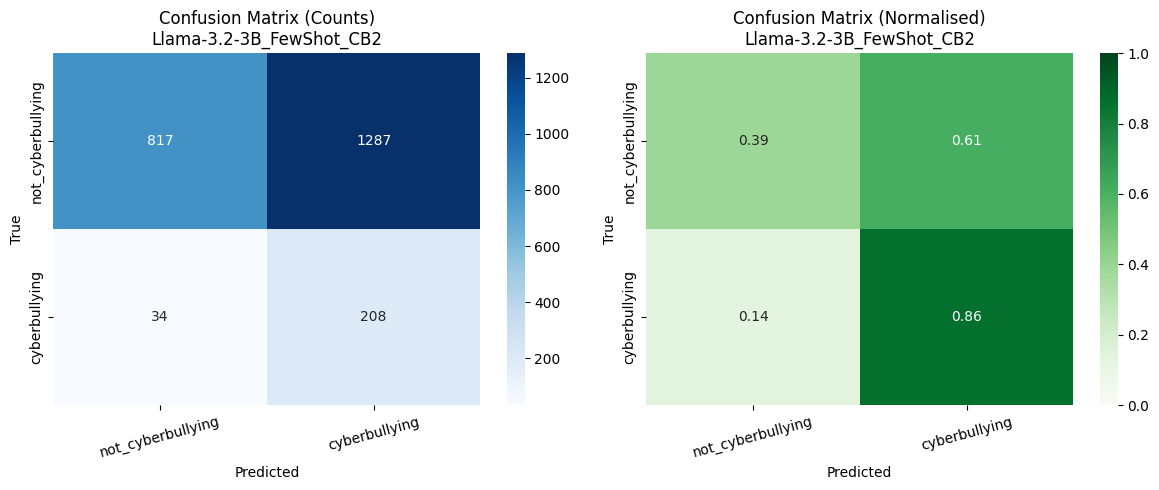

  Saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/cm_Llama-3.2-3B_FewShot_CB2.png


In [14]:
print("=" * 65)
print("FEW-SHOT INFERENCE — CB2 Binary")
print(f"  Model      : {MODEL_NAME}")
print(f"  Examples   : {len(few_shot_examples)} total "
      f"({N_EXAMPLES_PER_CLASS}/class × {NUM_LABELS} classes)")
print(f"  max_length : {MAX_INPUT_LEN_FS} tokens")
print("=" * 65)

_smoke_conv   = "You are so stupid | Nobody likes you | Get lost loser"
_smoke_prompt = build_prompt(_smoke_conv, few_shot_examples)
_smoke_inputs = tokenizer(
    _smoke_prompt, return_tensors="pt",
    truncation=True, max_length=MAX_INPUT_LEN_FS
).to(model.device)
_smoke_in_len = _smoke_inputs["input_ids"].shape[1]

with torch.no_grad():
    _smoke_out = model.generate(
        **_smoke_inputs, max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False, pad_token_id=tokenizer.eos_token_id
    )

_smoke_generated = tokenizer.decode(
    _smoke_out[0][_smoke_in_len:], skip_special_tokens=True
).strip()
_smoke_pred = parse_label(_smoke_generated)

print(f"Smoke test (Few-shot):")
print(f"  Input      : '{_smoke_conv}'")
print(f"  Generated  : '{_smoke_generated}'   <- must be 0 or 1")
print(f"  Prediction : {_smoke_pred} = {ID2LABEL[_smoke_pred]}")
print()

_valid = any(ch in _smoke_generated for ch in "01")
if not _valid:
    print("WARNING: smoke test did not produce 0 or 1. STOP and investigate.")
else:
    print("Smoke test PASSED. Proceeding with full few-shot run...")

y_pred_fs  = run_inference(x_test, examples=few_shot_examples,
                            desc="Few-shot", max_input_len=MAX_INPUT_LEN_FS)
results_fs = evaluate_dataset(y_test, y_pred_fs,
                               f"{MODEL_SHORT}_FewShot_CB2")
results_fs["regime"] = "few-shot"

---
## Step 15: Comparison

COMPARISON -- Llama-3.2-3B | Zero-Shot vs Few-Shot | CB2 (Binary)
   Regime  Macro F1    MCC  AUC-ROC  Binary F1  Accuracy  Macro P  Macro R
Zero-Shot    0.2922 0.0189   0.5135     0.1872    0.3078   0.5066   0.5135
 Few-Shot    0.3962 0.1568   0.6239     0.2395    0.4369   0.5496   0.6239


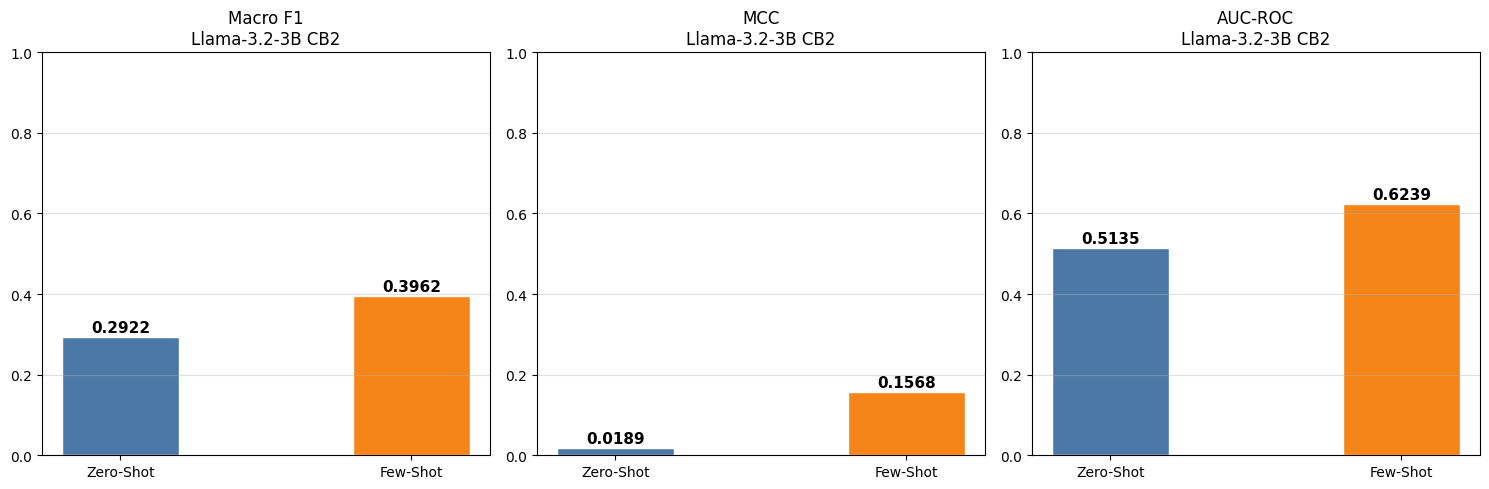

Chart saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/zs_vs_fs_comparison.png


In [15]:
all_results = [results_zs, results_fs]
regimes     = ["Zero-Shot", "Few-Shot"]

rows = []
for r, regime in zip(all_results, regimes):
    rows.append({
        "Regime":      regime,
        "Macro F1":    round(r["macro_f1"],          4),
        "MCC":         round(r["mcc"],               4),
        "AUC-ROC":     round(r["auc_roc"],           4),
        "Binary F1":   round(r["binary_f1"],         4),
        "Accuracy":    round(r["accuracy"],          4),
        "Macro P":     round(r["macro_precision"],   4),
        "Macro R":     round(r["macro_recall"],      4),
    })

print("=" * 80)
print(f"COMPARISON -- {MODEL_SHORT} | Zero-Shot vs Few-Shot | CB2 (Binary)")
print("=" * 80)
print(pd.DataFrame(rows).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#4c78a8", "#f58518"]

for ax, key, title in [
    (axes[0], "macro_f1", f"Macro F1\n{MODEL_SHORT} CB2"),
    (axes[1], "mcc",      f"MCC\n{MODEL_SHORT} CB2"),
    (axes[2], "auc_roc",  f"AUC-ROC\n{MODEL_SHORT} CB2"),
]:
    vals = [r[key] for r in all_results]
    bars = ax.bar(regimes, vals, color=colors, edgecolor="white", width=0.4)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{v:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_title(title, fontsize=12)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, "zs_vs_fs_comparison.png")
plt.savefig(path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved -> {path}")

---
## Step 16: Save Results

In [16]:
csv_path = os.path.join(OUTPUT_DIR, "summary_metrics.csv")
pd.DataFrame([{
    "model":             MODEL_NAME,
    "model_short":       MODEL_SHORT,
    "stage":             f'Stage1g_{r["regime"].replace("-","")}_CB2',
    "dataset":           "CB2",
    "regime":            r["regime"],
    "output_format":     "numeric_0_1",
    "text_repr":         f"concat_conv_max{MAX_CONV_WORDS}words",
    "test_samples":      len(y_test),
    "macro_f1":          round(r["macro_f1"],          4),
    "mcc":               round(r["mcc"],               4),
    "auc_roc":           round(r["auc_roc"],           4),
    "binary_f1":         round(r["binary_f1"],         4),
    "accuracy":          round(r["accuracy"],          4),
    "macro_precision":   round(r["macro_precision"],   4),
    "macro_recall":      round(r["macro_recall"],      4),
    "weighted_f1":       round(r["weighted_f1"],       4),
    "balanced_accuracy": round(r["balanced_accuracy"], 4),
} for r in all_results]).to_csv(csv_path, index=False)
print(f"Summary CSV saved -> {csv_path}")

for r, y_pred, regime in zip(all_results,
                              [y_pred_zs, y_pred_fs],
                              ["ZeroShot", "FewShot"]):
    pred_df = test_df[["text", "label", "user1", "user2"]].copy()
    pred_df["pred_id"]    = y_pred
    pred_df["pred_label"] = [ID2LABEL[p] for p in y_pred]
    pred_df["correct"]    = (test_df["label"].values == pred_df["pred_label"].values)
    ppath = os.path.join(OUTPUT_DIR, f"predictions_{regime}_CB2.csv")
    pred_df.to_csv(ppath, index=False)
    print(f"Predictions saved -> {ppath}")

print(f"\nAll outputs in: {OUTPUT_DIR}")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.isfile(fpath):
        print(f"  {fname:<50} {os.path.getsize(fpath)/1024:.1f} KB")

Summary CSV saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/summary_metrics.csv
Predictions saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/predictions_ZeroShot_CB2.csv
Predictions saved -> /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B/predictions_FewShot_CB2.csv

All outputs in: /content/drive/MyDrive/Results/CB2_Decoders/Llama-3.2-3B
  cm_Llama-3.2-3B_FewShot_CB2.png                    73.5 KB
  cm_Llama-3.2-3B_ZeroShot_CB2.png                   74.0 KB
  predictions_FewShot_CB2.csv                        3050.5 KB
  predictions_ZeroShot_CB2.csv                       3049.8 KB
  summary_metrics.csv                                0.5 KB
  zs_vs_fs_comparison.png                            44.1 KB


---
## Step 17: Research Summary

In [17]:
summary = f"""
=============================================================================
STAGE 1g — CB2 DECODER BASELINE: {MODEL_NAME}
CB2 (Binary, Conversation-Level) | Numeric Labels | Generalised LoRA
=============================================================================

MODEL
  {MODEL_NAME}
  ~3.2B parameters | 4-bit NF4 | float16 | system role supported

DATASET: CB2
  Task      : Binary conversation-level cyberbullying detection
  Samples   : 9,511 user pairs (100 school students)
  Imbalance : 8.6:1 (89.6% not_cb | 10.4% cyberbullying)
  Text      : All messages per pair concatenated, max 300 words
  Split     : 75/25 stratified, seed=42, TF-IDF dedup @0.90

IMPLEMENTATION
  Output format : numeric 0/1 (binary)
  Decode        : outputs[0][input_len:] — new tokens only
  Parser        : digit-first (0/1 only), word-boundary L2 fallback
  max_length    : ZS={MAX_INPUT_LEN_ZS}, FS={MAX_INPUT_LEN_FS}
  Few-shot      : {N_EXAMPLES_PER_CLASS} per class = {N_EXAMPLES_PER_CLASS * NUM_LABELS} total examples
  Decoding      : greedy (do_sample=False) — deterministic

RESULTS
  Zero-shot Macro F1 : {{results_zs['macro_f1']:.4f}}  MCC: {{results_zs['mcc']:.4f}}  AUC-ROC: {{results_zs['auc_roc']:.4f}}
  Few-shot  Macro F1 : {{results_fs['macro_f1']:.4f}}  MCC: {{results_fs['mcc']:.4f}}  AUC-ROC: {{results_fs['auc_roc']:.4f}}
"""
print(summary)


STAGE 1g — CB2 DECODER BASELINE: meta-llama/Llama-3.2-3B-Instruct
CB2 (Binary, Conversation-Level) | Numeric Labels | Generalised LoRA

MODEL
  meta-llama/Llama-3.2-3B-Instruct
  ~3.2B parameters | 4-bit NF4 | float16 | system role supported

DATASET: CB2
  Task      : Binary conversation-level cyberbullying detection
  Samples   : 9,511 user pairs (100 school students)
  Imbalance : 8.6:1 (89.6% not_cb | 10.4% cyberbullying)
  Text      : All messages per pair concatenated, max 300 words
  Split     : 75/25 stratified, seed=42, TF-IDF dedup @0.90

IMPLEMENTATION
  Output format : numeric 0/1 (binary)
  Decode        : outputs[0][input_len:] — new tokens only
  Parser        : digit-first (0/1 only), word-boundary L2 fallback
  max_length    : ZS=512, FS=1536
  Few-shot      : 2 per class = 4 total examples
  Decoding      : greedy (do_sample=False) — deterministic

RESULTS
  Zero-shot Macro F1 : {results_zs['macro_f1']:.4f}  MCC: {results_zs['mcc']:.4f}  AUC-ROC: {results_zs['auc_roc